Importa as bibliotecas necessárias

In [13]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

a)       Faça o download dos dados do arquivo data.mat ou data.csv. A primeira coluna é o tamanho da casa, a segunda coluna é o número de quartos, e a terceira coluna é o preço da casa.

In [14]:
df = pd.read_csv("data.csv", header=None, names=['tamanho', 'quartos', 'preco'])

b)      Utilize o comando python .describe()para fazer uma primeira análise estatística da sua base de dados. Qual a média de preço das casas? Quanto custa a menor casa? Quantos quartos tem a casa mais cara?

In [15]:
dados = df.values.tolist()

print(df.describe())

           tamanho    quartos          preco
count    47.000000  47.000000      47.000000
mean   2000.680851   3.170213  340412.765957
std     794.702354   0.760982  125039.911223
min     852.000000   1.000000  169900.000000
25%    1432.000000   3.000000  249900.000000
50%    1888.000000   3.000000  299900.000000
75%    2269.000000   4.000000  384450.000000
max    4478.000000   5.000000  699900.000000


  A média de preço é: R$ 340.412,76

  A menor casa custa: R$ 169.900,00
  
  A quantidade de quartos da casa mais cara: 5

Implementação dos métodos para gerar os gráficos e fazer os cálculos.

In [16]:
def gera_grafico_dispersao(x: list[float], y: list[float], label_x: str, label_y: str, titulo: str = 'Diagrama de dispersao'):
    """
    gera o diagrama de dispersao para os vetores x e y fornecidos
    """
    plt.scatter(x, y)
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.title(titulo)
    plt.grid(True)
    plt.autoscale()


def correlacao(vetor1: list[float], vetor2: list[float]) -> float:
    """
    Funcao responsavel por realizar o calculo do
    coeficiente de correlacao entre os dados
    """
    n = len(vetor1)
    media_x = sum(vetor1) / n
    media_y = sum(vetor2) / n

    numerador = sum((vetor1[i] - media_x) * (vetor2[i] - media_y) for i in range(n))
    denominador = math.sqrt(
        sum((vetor1[i] - media_x) ** 2 for i in range(n)) *
        sum((vetor2[i] - media_y) ** 2 for i in range(n))
    )

    return numerador / denominador


def regressao(vetor1: list[float], vetor2: list[float]):
    """
    Calcula os coef beta0 e beta1 da reta de regressao linear
    """
    n = len(vetor1)
    media_x = sum(vetor1) / n
    media_y = sum(vetor2) / n

    beta1 = (
        sum((vetor1[i] - media_x) * (vetor2[i] - media_y) for i in range(n)) /
        sum((vetor1[i] - media_x) ** 2 for i in range(n))
    )
    beta0 = media_y - beta1 * media_x

    return beta0, beta1


def le_dados(caminho_arquivo: str):
    """
    le o arquivo csv e retorna os dados
    """
    return pd.read_csv(caminho_arquivo, header=None).values.tolist()


def calcula_beta_multipla(matriz: list[list], vetor_y: list):
    """
    calcula o vetor beta da regressao multipla pela formula:
    beta = (X'X)^-1 * X' * y
    """
    matriz_transposta = np.transpose(matriz)
    prod_transp_matriz = matriz_transposta @ matriz
    matriz_inversa = np.linalg.inv(prod_transp_matriz)
    prod_inver_transp = matriz_inversa @ matriz_transposta
    beta = prod_inver_transp @ vetor_y

    return beta


def regressao_multipla(beta:list, tamanho:float, quarto:int):
    """
    calcula o preco usando os coeficientes beta
    """
    return beta[0] + beta[1] * tamanho + beta[2] * quarto


def gera_matriz(dados: list[list]) -> tuple[list[list], list]:
    X: list[list] = []
    y: list = []

    for linha in dados:
        X.append([1, linha[0], linha[1]])
        y.append(linha[2])

    return np.array(X), np.array(y)


def gera_vetores(dados: list[list]) -> tuple[list, list, list]:
    """
    Recebe os dados e retorna os vetores individuais de cada parametro
    """
    vetor_tamanho: list = []
    vetor_quarto: list = []
    vetor_preco: list = []

    for linha in dados:
        vetor_tamanho.append(linha[0])
        vetor_quarto.append(linha[1])
        vetor_preco.append(linha[2])

    return vetor_tamanho, vetor_quarto, vetor_preco

c)  Gere uma matriz X para as variáveis ​​independentes (que são o tamanho da casa e o número de quartos) e o vetor y da variável dependente (que é o preço).



d)      Verifique a correlação e a regressão para Tamanho da casa e Preço, e, Número de quartos e Preço e apresente os valores no gráfico de dispersão.

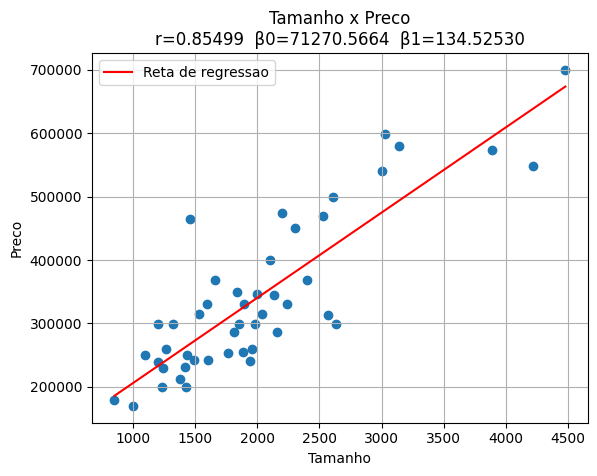

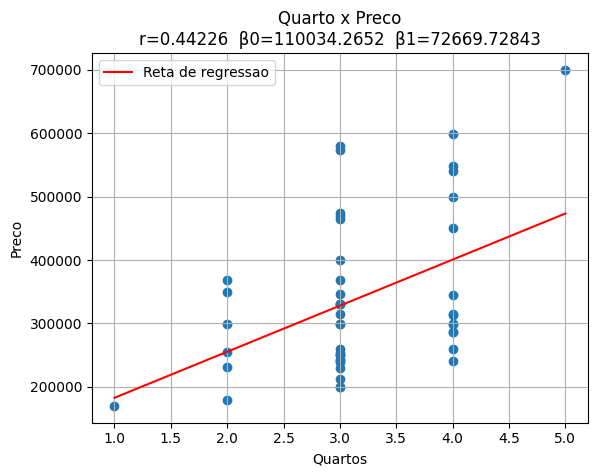

In [17]:
matriz, vetor_y = gera_matriz(dados)

v_tamanho, v_quarto, v_preco = gera_vetores(dados)
c_tam_prec = correlacao(v_tamanho, v_preco)
tamPre0, tamPre1 = regressao(v_tamanho, v_preco)
c_qua_prec = correlacao(v_quarto, v_preco)
quaPrec0, quaPrec1 = regressao(v_quarto, v_preco)

gera_grafico_dispersao(v_tamanho, v_preco, label_x='Tamanho', label_y='Preco') # c e d
x_linha_tam = [min(v_tamanho), max(v_tamanho)]
y_linha_tam_prec = [tamPre0 + tamPre1 * xi for xi in x_linha_tam]
plt.plot(x_linha_tam, y_linha_tam_prec, color='red', label='Reta de regressao')
plt.title(f'Tamanho x Preco\nr={c_tam_prec:.5f}  β0={tamPre0:.4f}  β1={tamPre1:.5f}')
plt.legend()
plt.show()

gera_grafico_dispersao(v_quarto, v_preco, label_x='Quartos', label_y='Preco')  # c e d
x_linha_qua = [min(v_quarto), max(v_quarto)]
y_linha_qua_prec = [quaPrec0 + quaPrec1 * xi for xi in x_linha_qua]
plt.plot(x_linha_qua, y_linha_qua_prec, color='red', label='Reta de regressao')
plt.title(f'Quarto x Preco\nr={c_qua_prec:.5f}  β0={quaPrec0:.4f}  β1={quaPrec1:.5f}')
plt.legend()
plt.show()

e)     Calcule a Regressão Múltipla. Faça o gráfico de dispersão em 3D com o tamanho da casa, número de quartos, e o preço da casa. Neste caso iremos trabalhar com o espaço 3D (verifique como usar Axes3D).

f)        Trace a linha da regressão no Gráfico de Dispersão. Você pode girar este gráfico para visualizar melhor os dados.

g)       Mostre na figura os coeficientes de correlação entre Tamanho da casa e Preço e Número de quartos e Preço.

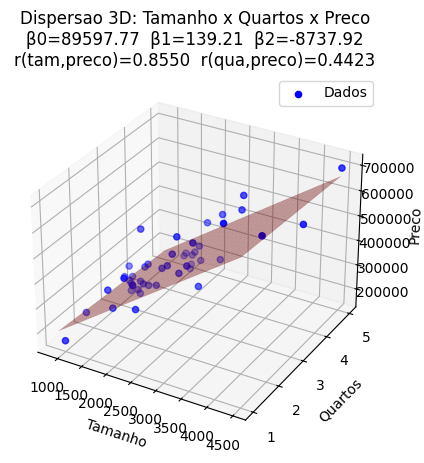

In [18]:
beta = calcula_beta_multipla(matriz, vetor_y) # e

tam_range = np.linspace(min(v_tamanho), max(v_tamanho), 20) # e
qua_range = np.linspace(min(v_quarto), max(v_quarto), 20) # e
TAM, QUA = np.meshgrid(tam_range, qua_range) # e
PRECO_SUPERFICIE = regressao_multipla(beta, TAM, QUA) # e

figura = plt.figure() # e
ax = figura.add_subplot(111, projection='3d') # e
ax.scatter(v_tamanho, v_quarto, v_preco, color='blue', label='Dados') # e
ax.plot_surface(TAM, QUA, PRECO_SUPERFICIE, alpha=0.4, color='red') # f

ax.set_xlabel('Tamanho') # g
ax.set_ylabel('Quartos') # g
ax.set_zlabel('Preco') # g
ax.set_title( # g
  f'Dispersao 3D: Tamanho x Quartos x Preco\n'
  f'β0={beta[0]:.2f}  β1={beta[1]:.2f}  β2={beta[2]:.2f}\n'
  f'r(tam,preco)={c_tam_prec:.4f}  r(qua,preco)={c_qua_prec:.4f}'
)
ax.legend() # g
plt.show() # g

h)      Calcule o preço de uma casa que tem tamanho de 1650 e 3 quartos. O resultado deve ser igual a 293081. Aumente e diminua a quantidade de número de quartos. O que acontece? Por qual motivo?

In [19]:
tamanho_casa = 1650 # h
quartos = 3 # h
preco = regressao_multipla(beta, tamanho_casa, quartos)  # h
print(f"Preco previsto: {preco:.0f}") # h

for q in range(1, 6): # i
  p = regressao_multipla(beta, tamanho_casa, q) # i
  print(f"  Quartos={q} = Preco: {p:.0f}") # i

Preco previsto: 293082
  Quartos=1 = Preco: 310557
  Quartos=2 = Preco: 301819
  Quartos=3 = Preco: 293082
  Quartos=4 = Preco: 284344
  Quartos=5 = Preco: 275606


  Notamos que o preco tende a diminuir conforme a quantidade de quartos
  A correlação é ruim
  Temos poucos dados
  A variância de preço para uma casa com a mesma quantidade de quartos é muito alta

i)        Compare seus resultados com a função de regressão linear múltipla do python. Para isso você irá precisar das bibliotecas numpy e scikit-learn.

In [20]:
x_sklearn = np.column_stack((v_tamanho, v_quarto))
modelo = LinearRegression()
modelo.fit(x_sklearn, v_preco)

beta0_sk = modelo.intercept_
beta1_sk, beta2_sk = modelo.coef_

print("\n--- Comparação dos coeficientes ---")
print(f"{'':20} {'Manual':>12} {'Scikit-learn':>12}")
print(f"{'β0 (intercepto)':20} {beta[0]:>12.4f} {beta0_sk:>12.4f}")
print(f"{'β1 (tamanho)':20} {beta[1]:>12.4f} {beta1_sk:>12.4f}")
print(f"{'β2 (quartos)':20} {beta[2]:>12.4f} {beta2_sk:>12.4f}")

preco_sk = modelo.predict([[tamanho_casa, quartos]])[0]
print(f"\nPrevisão para {tamanho_casa} m², {quartos} quartos:")
print(f"  Manual:       {preco:.0f}")
print(f"  Scikit-learn: {preco_sk:.0f}")


--- Comparação dos coeficientes ---
                           Manual Scikit-learn
β0 (intercepto)        89597.7660   89597.7660
β1 (tamanho)             139.2106     139.2106
β2 (quartos)           -8737.9154   -8737.9154

Previsão para 1650 m², 3 quartos:
  Manual:       293082
  Scikit-learn: 293082


Notamos que os valores dos calculos que desenvolvemos e da biblioteca geram os mesmos resultados